In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow.keras as keras
from keras import models
from keras import layers


### Q1

##### (a) Replicate the linear classification example in class for the binary classification of purple/orange colors based off luminance and saturation.

In [2]:
color1=np.random.uniform(low=[200,80,0],high=[255,188,70],size=(300,3))/255.0
color2=np.random.uniform(low=[100,0,110],high=[200,130,255],size=(300,3))/255.0
colors=np.concatenate((color1,color2),axis=0)

In [3]:
luminance=0.2126*colors[:,0]+0.7152*colors[:,1]+0.0722*colors[:,2]

In [4]:
max_rgb = np.max(colors,axis=1)
min_rgb = np.min(colors,axis=1)
saturation= (max_rgb-min_rgb)/(max_rgb+1e-6)

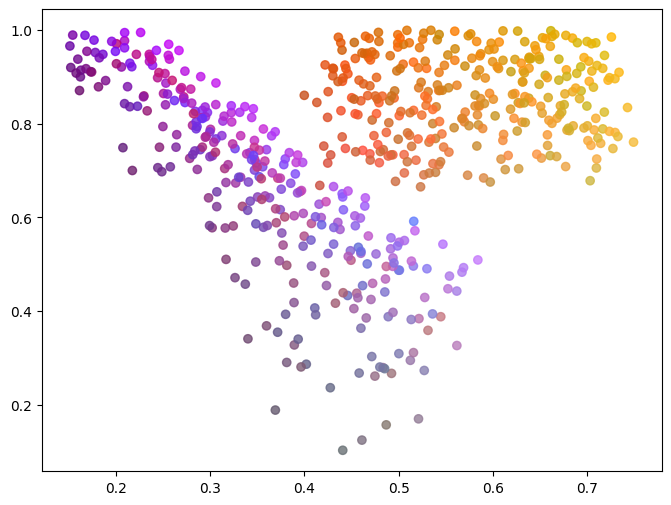

In [5]:
plt.figure(figsize=(8,6))
plt.scatter(luminance,saturation,c=colors,alpha=0.8)
plt.show()

In [6]:
inputs=np.stack([luminance,saturation],axis=1,dtype=np.float32)
labels=np.array([1]*300+[0]*300,dtype=np.float32)

In [7]:
def square_loss(y_true,y_pred):
    return tf.reduce_mean(tf.square(y_true-y_pred))

In [8]:
input_dim=2
output_dim=1
W = tf.Variable(initial_value=tf.random.uniform(shape=(input_dim, output_dim)))
b = tf.Variable(initial_value=tf.zeros(shape=(output_dim,)))

def model(inputs):
    return tf.matmul(inputs, W) + b

In [9]:
learning_rate = 0.1
def training_step(inputs, labels):
    with tf.GradientTape() as tape:
        predictions = model(inputs)
        loss = square_loss(predictions, labels)
        grad_W, grad_b = tape.gradient(loss, [W, b])
        W.assign_sub(learning_rate * grad_W)
        b.assign_sub(learning_rate * grad_b)
        return loss

In [10]:
for step in range(40):
    loss = training_step(inputs, labels)
    print(f"Loss at step {step}: {loss:.4f}")

Loss at step 0: 0.2631
Loss at step 1: 0.2607
Loss at step 2: 0.2597
Loss at step 3: 0.2593
Loss at step 4: 0.2590
Loss at step 5: 0.2589
Loss at step 6: 0.2588
Loss at step 7: 0.2588
Loss at step 8: 0.2587
Loss at step 9: 0.2586
Loss at step 10: 0.2586
Loss at step 11: 0.2585
Loss at step 12: 0.2585
Loss at step 13: 0.2584
Loss at step 14: 0.2584
Loss at step 15: 0.2583
Loss at step 16: 0.2582
Loss at step 17: 0.2582
Loss at step 18: 0.2581
Loss at step 19: 0.2581
Loss at step 20: 0.2580
Loss at step 21: 0.2580
Loss at step 22: 0.2579
Loss at step 23: 0.2579
Loss at step 24: 0.2578
Loss at step 25: 0.2578
Loss at step 26: 0.2577
Loss at step 27: 0.2577
Loss at step 28: 0.2576
Loss at step 29: 0.2576
Loss at step 30: 0.2575
Loss at step 31: 0.2575
Loss at step 32: 0.2574
Loss at step 33: 0.2574
Loss at step 34: 0.2573
Loss at step 35: 0.2573
Loss at step 36: 0.2572
Loss at step 37: 0.2572
Loss at step 38: 0.2571
Loss at step 39: 0.2571


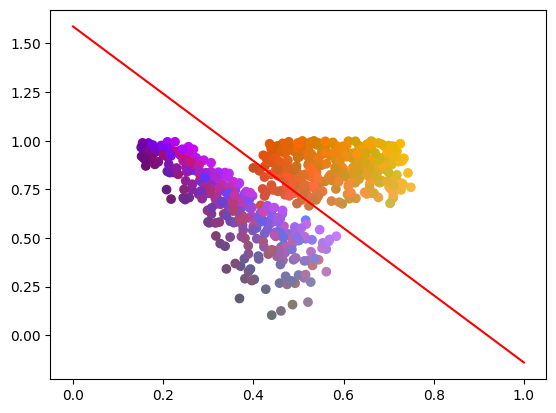

In [11]:
x = np.linspace(0, 1, 100)
y = -W[0]/W[1] * x + (0.5 - b) /W[1]
plt.plot(x, y, '-r')
plt.scatter(inputs[:, 0], inputs[:, 1], c=colors)
plt.show()

(b) Write a python function to use binary accuracy as a loss function. Use this loss function in place of the Mean Squared Error function and rerun your linear classification.

In [12]:
def bce_loss(y_true,y_pred):
    return -tf.reduce_mean(y_true*tf.math.log(y_pred+1e-6)+(1-y_true)*tf.math.log(1-y_pred+1e-6))

In [13]:
learning_rate = 0.1
def training_step(inputs, labels):
    with tf.GradientTape() as tape:
        predictions = model(inputs)
        loss = bce_loss(predictions, labels)
        grad_W, grad_b = tape.gradient(loss, [W, b])
        W.assign_sub(learning_rate * grad_W)
        b.assign_sub(learning_rate * grad_b)
        return loss

In [14]:
for step in range(40):
    loss = training_step(inputs, labels)
    print(f"Loss at step {step}: {loss:.4f}")

Loss at step 0: 6.9078
Loss at step 1: 6.9078
Loss at step 2: 6.9078
Loss at step 3: 6.9078
Loss at step 4: 6.9078
Loss at step 5: 6.9078
Loss at step 6: 6.9078
Loss at step 7: 6.9078
Loss at step 8: 6.9078
Loss at step 9: 6.9078
Loss at step 10: 6.9078
Loss at step 11: 6.9078
Loss at step 12: 6.9078
Loss at step 13: 6.9078
Loss at step 14: 6.9078
Loss at step 15: 6.9078
Loss at step 16: 6.9078
Loss at step 17: 6.9078
Loss at step 18: 6.9078
Loss at step 19: 6.9078
Loss at step 20: 6.9078
Loss at step 21: 6.9078
Loss at step 22: 6.9078
Loss at step 23: 6.9078
Loss at step 24: 6.9078
Loss at step 25: 6.9078
Loss at step 26: 6.9078
Loss at step 27: 6.9078
Loss at step 28: 6.9078
Loss at step 29: 6.9078
Loss at step 30: 6.9078
Loss at step 31: 6.9078
Loss at step 32: 6.9078
Loss at step 33: 6.9078
Loss at step 34: 6.9078
Loss at step 35: 6.9078
Loss at step 36: 6.9078
Loss at step 37: 6.9078
Loss at step 38: 6.9078
Loss at step 39: 6.9078


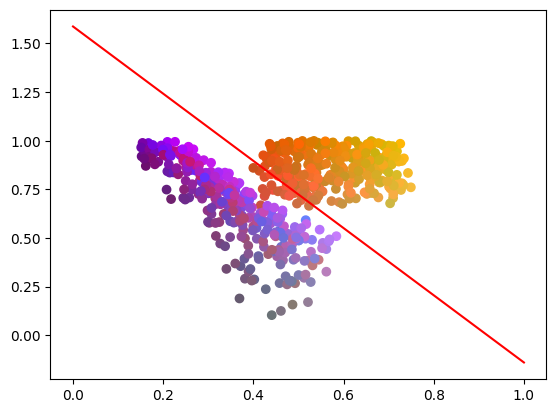

In [15]:
x = np.linspace(0, 1, 100)
y = -W[0]/W[1] * x + (0.5 - b) /W[1]
plt.plot(x, y, '-r')
plt.scatter(inputs[:, 0], inputs[:, 1], c=colors)
plt.show()

(c) How does the change of the loss function impact your model’s performance?

Replacing MSE with Binary Crossentropy improves model performance because BCE is more ideal for classification tasks.

### Q2
The Bot Adversarial Dialogue (BAD) dataset from TensorFlow Datasets (TFDS) is designed for
evaluating the safety of chatbot models that contains conversations where users exploit
weaknesses in AI chatbots. The “text” values are responses from a chatbot model.




(a) Import the Bot Adversarial Dialogue dataset from the TensorFlow Datasets package in python.

In [16]:
# import tensorflow_datasets as tfds

# dataset = tfds.load("bot_adversarial_dialogue")
# train_dataset = dataset["train"]
# test_dataset = dataset["test"]

# train_texts = [example["text"].numpy().decode("utf-8") for example in train_dataset]
# train_labels = [example["label"].numpy() for example in train_dataset]
# test_texts = [example["text"].numpy().decode("utf-8") for example in test_dataset]
# test_labels = [example["label"].numpy() for example in test_dataset]


In [17]:
import pickle

# Load dataset
with open("BAD_dataset.pkl", "rb") as f:
    data = pickle.load(f)

train_texts = data['train_texts']
train_labels = data['train_labels']
test_texts = data['test_texts']
test_labels = data['test_labels']

print("Dataset loaded from dataset.pkl")

Dataset loaded from dataset.pkl


(b) Convert the text to a sequence of numbers, then Multi-Hot encode your text data.

In [18]:
vectorize_layer = tf.keras.layers.TextVectorization(
    max_tokens=10000,
    output_mode='int')
vectorize_layer.adapt(train_texts)

In [19]:
train_sequences = vectorize_layer(train_texts)
test_sequences = vectorize_layer(test_texts)

In [20]:
def vectorize_sequences(sequences, dimension=10000):
    results = np.zeros((len(sequences), dimension))
    for i, sequence in enumerate(sequences):
        results[i, sequence] = 1
    return results

train_seq_encoded = vectorize_sequences(train_sequences.numpy())
test_seq_encoded = vectorize_sequences(test_sequences.numpy())

In [21]:
print(train_seq_encoded)
print(train_seq_encoded.shape)

[[1. 0. 0. ... 0. 0. 0.]
 [1. 0. 0. ... 0. 0. 0.]
 [1. 1. 1. ... 0. 0. 0.]
 ...
 [1. 1. 0. ... 0. 0. 0.]
 [1. 1. 0. ... 0. 0. 0.]
 [1. 0. 0. ... 0. 0. 0.]]
(69274, 10000)


### Q3
Create a multi-layer neural network (reference the IMDB example in class) for a binary
classification of “Good” and “Bad” chatbot responses. In the BAD dataset, each “text” is a bot
response marked with a “label” to identify offensive or undesirable bot responses. Undesirable
responses are labeled with a 1. Desirable responses are marked with a 0

In [22]:
model = keras.Sequential([
    layers.Dense(64, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='rmsprop',
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [23]:
x_val = train_seq_encoded[:1000]
partial_x_train = train_seq_encoded[1000:]
y_val = np.array(train_labels[:1000])
partial_y_train = np.array(train_labels[1000:])

In [24]:
history = model.fit(partial_x_train,
                    partial_y_train,
                    epochs=20,
                    batch_size=512,
                    validation_data=(x_val, y_val))

Epoch 1/20
134/134 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.6619 - loss: 0.5863 - val_accuracy: 0.7410 - val_loss: 0.4982
Epoch 2/20
134/134 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7569 - loss: 0.4860 - val_accuracy: 0.7570 - val_loss: 0.4787
Epoch 3/20
134/134 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7821 - loss: 0.4501 - val_accuracy: 0.7780 - val_loss: 0.4681
Epoch 4/20
134/134 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8018 - loss: 0.4215 - val_accuracy: 0.7860 - val_loss: 0.4628
Epoch 5/20
134/134 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8182 - loss: 0.3912 - val_accuracy: 0.7850 - val_loss: 0.4565
Epoch 6/20
134/134 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8428 - loss: 0.3557 - val_accuracy: 0.7810 - val_loss: 0.4743
Epoch 7/20
134/134 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8630 - loss: 0.3220 - val_accuracy: 0.7700 - val_loss: 0.5089
Epoch 8/20
134/134 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8833 - loss: 0.2827 - val_accuracy:

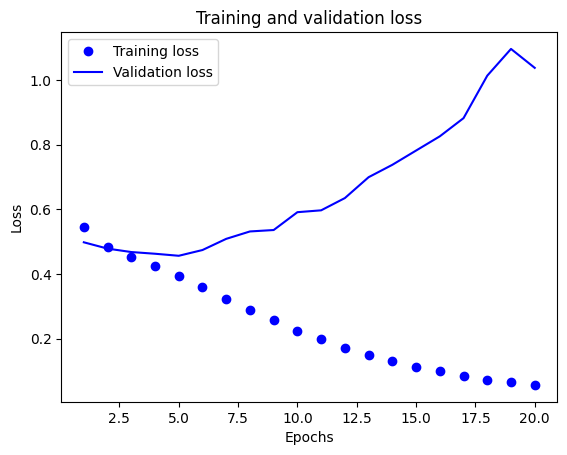

In [25]:
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(loss) + 1)
plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

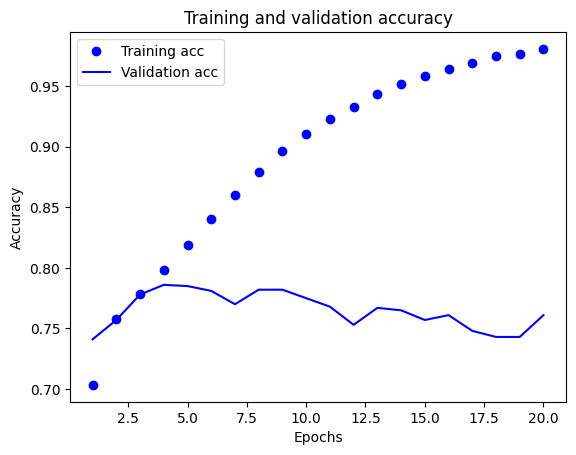

In [26]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
plt.plot(epochs, acc, 'bo', label='Training acc')
plt.plot(epochs, val_acc, 'b', label='Validation acc')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()